### Decision Tree Regressor

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [8]:
from sklearn.datasets import load_diabetes
X=load_diabetes()['data']
y=load_diabetes()['target']

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

In [23]:
pd.DataFrame(X_train).corr()

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
1,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
2,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
3,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
4,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
5,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
6,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
7,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
8,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
9,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

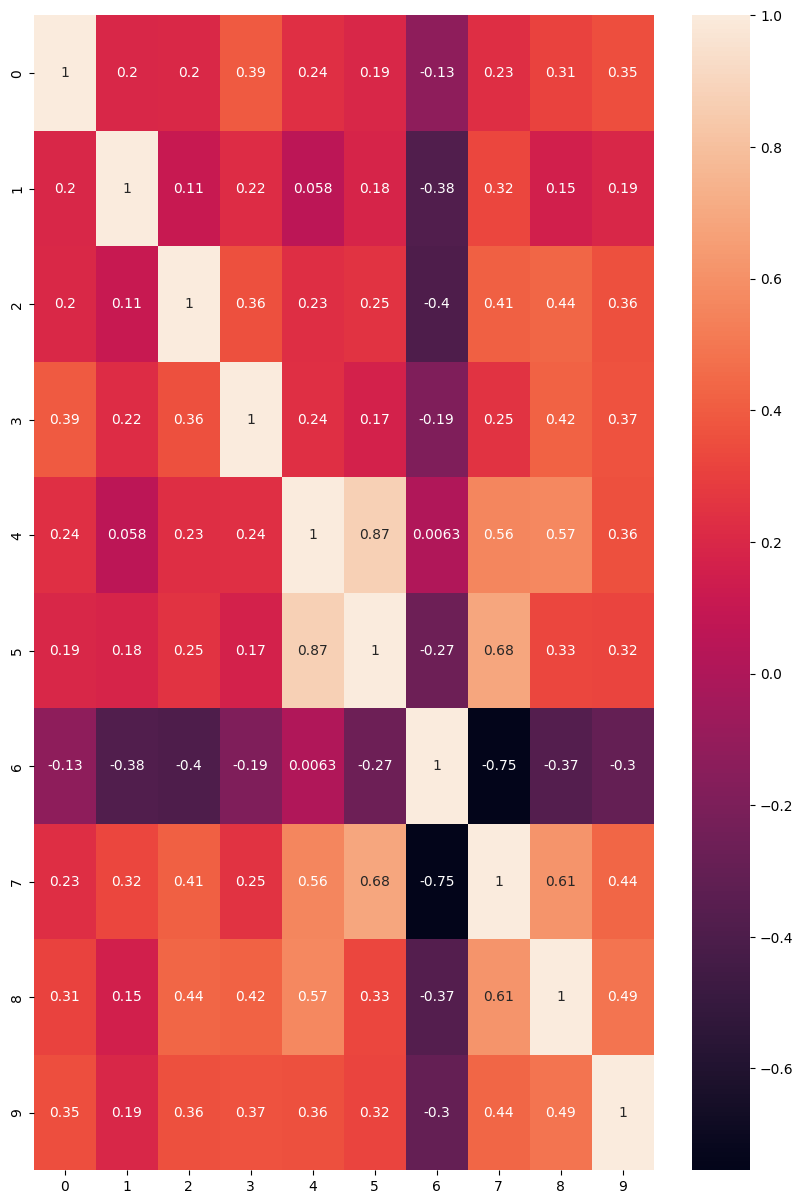

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,15))
sns.heatmap(pd.DataFrame(X_train).corr(),annot=True)

In [25]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
pipeline=Pipeline([
    ('dt',DecisionTreeRegressor())
])

param_grid = {
    'dt__criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'dt__splitter': ['best', 'random'],
    'dt__max_depth': [5,3,4,7,2,9] ,
    'dt__min_samples_split': [200,170,40,30,20,22,25] ,
    'dt__min_weight_fraction_leaf': [0.1,0.01,0.05],
    'dt__max_features': ['sqrt', 'log2',2,3]


}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=3
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'dt__criterion': ['squared_error', 'friedman_mse', ...], 'dt__max_depth': [5, 3, ...], 'dt__max_features': ['sqrt', 'log2', ...], 'dt__min_samples_split': [200, 170, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,3
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [27]:
grid.best_params_

{'dt__criterion': 'friedman_mse',
 'dt__max_depth': 4,
 'dt__max_features': 'log2',
 'dt__min_samples_split': 22,
 'dt__min_weight_fraction_leaf': 0.05,
 'dt__splitter': 'best'}

In [ ]:
y_pred=grid.predict(X_test)
from sklearn.metrics import r2_score
y_pred = .best_estimator_.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R2 score:", r2)

R2 score: 0.44177051144222856


In [ ]:
selectDT=DecisionTreeRegressor(criterion= 'friedman_mse',
 max_depth= 4,
 max_features= 'log2',
 min_samples_split= 22,
 min_weight_fraction_leaf= 0.05,
 splitter= 'best')
.fit(X_train, y_train)


,criterion,'friedman_mse'
,splitter,'best'
,max_depth,4
,min_samples_split,22
,min_samples_leaf,1
,min_weight_fraction_leaf,0.05
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [39]:
##Visualize Decision Tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(150,100))
tree.plot_tree(selectDT,filled=True)

[Text(0.5119047619047619, 0.9, 'x[2] <= 0.016\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.2619047619047619, 0.7, 'x[2] <= -0.022\nfriedman_mse = 3732.377\nsamples = 205\nvalue = 125.498'),
 Text(0.38690476190476186, 0.8, 'True  '),
 Text(0.09523809523809523, 0.5, 'x[6] <= -0.028\nfriedman_mse = 2259.279\nsamples = 106\nvalue = 104.406'),
 Text(0.047619047619047616, 0.3, 'friedman_mse = 2375.506\nsamples = 18\nvalue = 137.222'),
 Text(0.14285714285714285, 0.3, 'x[9] <= 0.013\nfriedman_mse = 1970.167\nsamples = 88\nvalue = 97.693'),
 Text(0.09523809523809523, 0.1, 'friedman_mse = 1491.805\nsamples = 69\nvalue = 92.188'),
 Text(0.19047619047619047, 0.1, 'friedman_mse = 3197.69\nsamples = 19\nvalue = 117.684'),
 Text(0.42857142857142855, 0.5, 'x[7] <= 0.025\nfriedman_mse = 4323.307\nsamples = 99\nvalue = 148.081'),
 Text(0.3333333333333333, 0.3, 'x[5] <= -0.027\nfriedman_mse = 3441.991\nsamples = 57\nvalue = 125.211'),
 Text(0.2857142857142857, 0.1, 'friedman_mse = 